## Linear Regression model with 1-year lag

First I'll create the lag features

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

file_path = "../data/raw/Modified_Prov_Type_and_Round_Int_All_10_years.csv"

usecols = [
    "year",
    "Rndrng_NPI",                
    "Rndrng_Prvdr_Type",
    "Tot_Benes",
    "Tot_Srvcs",
    "Drug_Tot_Srvcs",
    "Bene_Avg_Risk_Scre",
    "Tot_Mdcr_Pymt_Amt"
]

df = pd.read_csv(file_path, usecols=usecols, low_memory=False)
df = df.sort_values(["Rndrng_NPI", "year"])


df["lag_Tot_Mdcr_Pymt_Amt"] = (
    df.groupby("Rndrng_NPI")["Tot_Mdcr_Pymt_Amt"].shift(1)
)

df = df.dropna(subset=["lag_Tot_Mdcr_Pymt_Amt"])

df["log_Tot_Benes"] = np.log1p(df["Tot_Benes"])
df["log_Tot_Srvcs"] = np.log1p(df["Tot_Srvcs"])

df["Srvcs_per_Bene"] = df["Tot_Srvcs"] / df["Tot_Benes"].replace(0, np.nan)
df["Drug_Srvcs_Share"] = df["Drug_Tot_Srvcs"] / df["Tot_Srvcs"].replace(0, np.nan)
df["Drug_Srvcs_Share"] = df["Drug_Srvcs_Share"].fillna(0)

df["log_Tot_Mdcr_Pymt_Amt"] = np.log1p(df["Tot_Mdcr_Pymt_Amt"])
df["log_lag_payment"] = np.log1p(df["lag_Tot_Mdcr_Pymt_Amt"])

Note: Drug_Tot_Srvcs had ~10% missingness so I converted missing values to 0

In [32]:
corr = df["log_lag_payment"].corr(df["log_Tot_Mdcr_Pymt_Amt"])
print("Lag correlation:", corr)

Lag correlation: 0.8970329160124345


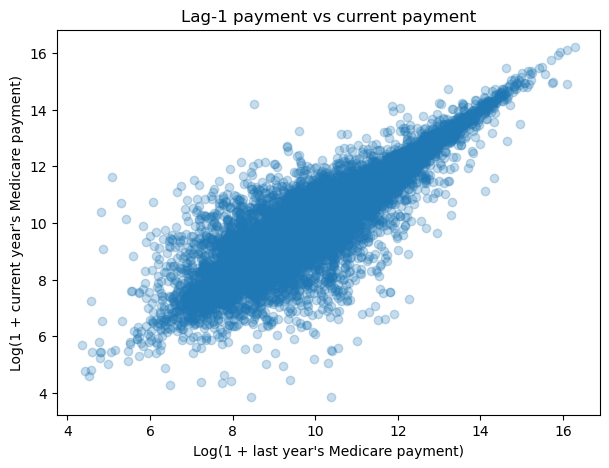

In [33]:
sample_df = df.sample(min(20000, len(df)), random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(
    sample_df["log_lag_payment"],
    sample_df["log_Tot_Mdcr_Pymt_Amt"],
    alpha=0.25
)
plt.xlabel("Log(1 + last year's Medicare payment)")
plt.ylabel("Log(1 + current year's Medicare payment)")
plt.title("Lag-1 payment vs current payment")
plt.show()

Now we must define our feature sets and do a Walk-forward evaluation loop

In [34]:
features_base = [
    "Rndrng_Prvdr_Type"
]

features_lag = [
    "Rndrng_Prvdr_Type",
    "log_lag_payment"
]

features_full = [
    "Rndrng_Prvdr_Type",
    "log_lag_payment",
    "log_Tot_Benes",
    "log_Tot_Srvcs",
    "Srvcs_per_Bene",
    "Drug_Srvcs_Share",
    "Bene_Avg_Risk_Scre"
]

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

target = "log_Tot_Mdcr_Pymt_Amt"

def walk_forward_eval(df, features, model):

    results = []
    years = sorted(df["year"].unique())

    for test_year in years:
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        log_ratio = preds - y_test

        results.append({
            "year": test_year,
            "n_train": len(train),
            "n_test": len(test),
            "metric_mean": log_ratio.mean(),
            "metric_abs": np.abs(log_ratio).mean()
        })

    return pd.DataFrame(results)



In [36]:


all_features_for_comparison = list(set(features_base + features_lag + features_full))
comparison_df = df[["year", target] + all_features_for_comparison].dropna().copy() #this ensures all models have the same rows, same providers, and same years

from sklearn.linear_model import LinearRegression

base_results = walk_forward_eval(comparison_df, features_base, LinearRegression())
lag_results  = walk_forward_eval(comparison_df, features_lag, LinearRegression())
full_results = walk_forward_eval(comparison_df, features_full, LinearRegression())

comparison = pd.DataFrame({
    "model": ["provider_type", "provider_type + lag", "full_features"],
    "mean_abs_log_ratio (error)": [
        base_results["metric_abs"].mean(),
        lag_results["metric_abs"].mean(),
        full_results["metric_abs"].mean()
    ]
})

comparison

,model,mean_abs_log_ratio (error)
0,provider_type,0.996717
1,provider_type + lag,0.408283
2,full_features,0.299216


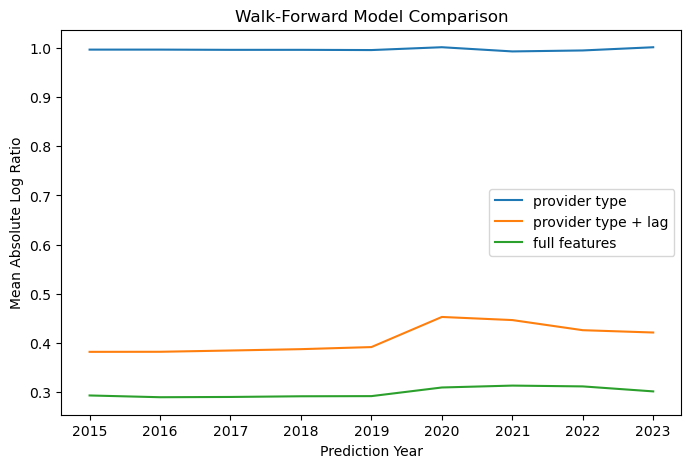

In [37]:
plt.figure(figsize=(8,5))

plt.plot(base_results["year"], base_results["metric_abs"], label="provider type")
plt.plot(lag_results["year"], lag_results["metric_abs"], label="provider type + lag")
plt.plot(full_results["year"], full_results["metric_abs"], label="full features")

plt.ylabel("Mean Absolute Log Ratio")
plt.xlabel("Prediction Year")
plt.legend()
plt.title("Walk-Forward Model Comparison")

plt.show()

# Now I'll try to add a Random Forest model instead of linear regression

In [38]:
from sklearn.ensemble import RandomForestRegressor

def walk_forward_eval(df, features, model):

    results = []
    years = sorted(df["year"].unique())

    for test_year in years:

        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        log_ratio = preds - y_test

        results.append({
            "year": test_year,
            "n_train": len(train),
            "n_test": len(test),
            "metric_mean": log_ratio.mean(),
            "metric_abs": np.abs(log_ratio).mean()
        })

    return pd.DataFrame(results)

In [41]:
rf_df = comparison_df.sample(300000, random_state=42).copy()

In [42]:
from sklearn.linear_model import LinearRegression

lr_results = walk_forward_eval(
    comparison_df,
    features_full,
    LinearRegression()
)

from sklearn.ensemble import RandomForestRegressor

rf_results = walk_forward_eval(
    rf_df,
    features_full,
    RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )
)

In [43]:
lr_results

,year,n_train,n_test,metric_mean,metric_abs
0,2015,895535,933669,-0.008683,0.293282
1,2016,1829204,969933,0.007730,0.289710
2,2017,2799137,1005533,0.008668,0.290243
3,2018,3804670,1038219,-0.003146,0.291639
4,2019,4842889,1069792,-0.018816,0.291944
5,2020,5912681,1082567,0.040560,0.309515
6,2021,6995248,1107248,-0.117677,0.313353
7,2022,8102496,1136672,-0.027094,0.311711
8,2023,9239168,1167621,-0.053875,0.301548


In [44]:
rf_results

,year,n_train,n_test,metric_mean,metric_abs
0,2015,26065,26987,-0.009010,0.256213
1,2016,53052,28082,0.010100,0.246040
2,2017,81134,29013,0.008616,0.246047
3,2018,110147,29685,-0.002209,0.245672
4,2019,139832,30688,-0.017142,0.248560
5,2020,170520,31235,0.067289,0.278590
6,2021,201755,31823,-0.123776,0.278679
7,2022,233578,32788,-0.005617,0.261052
8,2023,266366,33634,-0.028738,0.255637


In [45]:
model_comparison = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest"],
    "mean_abs_log_ratio": [
        lr_results["metric_abs"].mean(),
        rf_results["metric_abs"].mean()
    ]
})

model_comparison

,model,mean_abs_log_ratio
0,Linear Regression,0.299216
1,Random Forest,0.257388


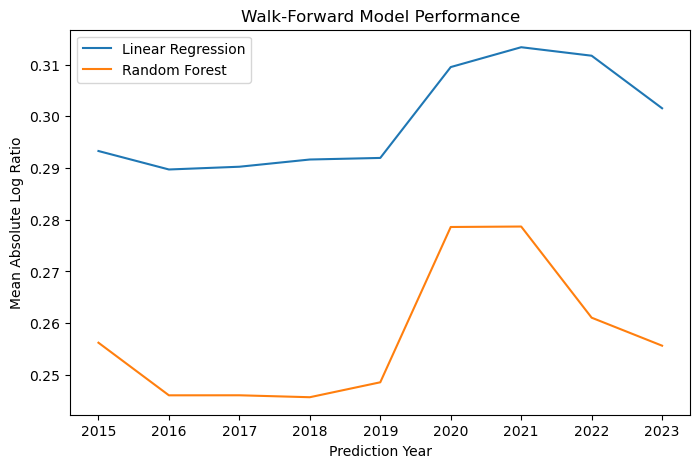

In [46]:
plt.figure(figsize=(8,5))

plt.plot(lr_results["year"], lr_results["metric_abs"], label="Linear Regression")
plt.plot(rf_results["year"], rf_results["metric_abs"], label="Random Forest")

plt.xlabel("Prediction Year")
plt.ylabel("Mean Absolute Log Ratio")
plt.title("Walk-Forward Model Performance")

plt.legend()
plt.show()

In [47]:
def get_predictions(df, features, model):

    years = sorted(df["year"].unique())
    preds_list = []

    for test_year in years:
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = pd.get_dummies(train[features], drop_first=True)
        X_test  = pd.get_dummies(test[features], drop_first=True)

        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        y_train = train[target]
        y_test  = test[target]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        temp = pd.DataFrame({
            "actual_log": y_test,
            "pred_log": preds
        })

        preds_list.append(temp)

    return pd.concat(preds_list)

In [48]:
pred_df = get_predictions(
    comparison_df,
    features_full,
    LinearRegression()
)

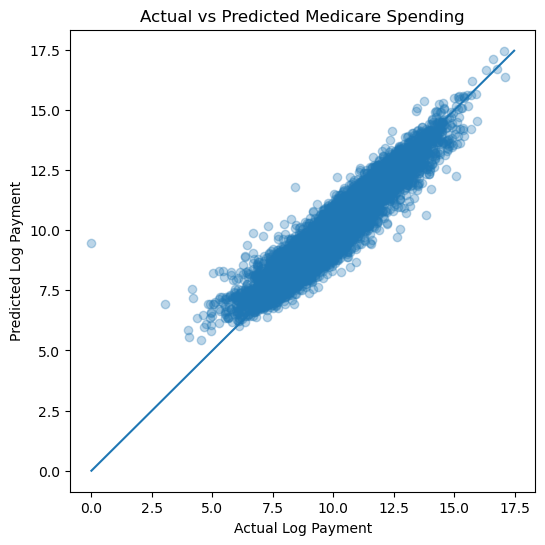

In [49]:
sample = pred_df.sample(20000, random_state=42)

plt.figure(figsize=(6,6))

plt.scatter(sample["actual_log"], sample["pred_log"], alpha=0.3)

lims = [
    min(sample["actual_log"].min(), sample["pred_log"].min()),
    max(sample["actual_log"].max(), sample["pred_log"].max())
]

plt.plot(lims, lims)

plt.xlabel("Actual Log Payment")
plt.ylabel("Predicted Log Payment")
plt.title("Actual vs Predicted Medicare Spending")

plt.show()

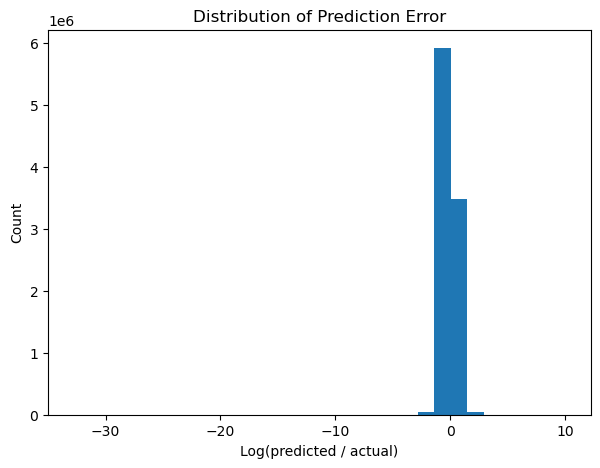

In [55]:
log_ratio = pred_df["pred_log"] - pred_df["actual_log"]

plt.figure(figsize=(7,5))
plt.hist(log_ratio, bins=30)
plt.xlabel("Log(predicted / actual)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Error")
plt.show()